# The small run, stage by stage

d=3, 12 rounds, 3 sliding windows, seed 8: one detector fires in round 11
and the observable really flips. First the run is assembled here, piece by
piece, straight from decsim. Then each cell prints what one stage receives
and what it sends on, with timestamps. Hand formulas: README section 1.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "guide" / "walkthrough"))
sys.path.insert(0, str(repo_root))
print(repo_root)

/scratch/gpfs/MARTONOSI/sk2415/qlx-qec-sandbox/decsim


## The yaml: every cost of the experiment

In [2]:
import yaml

CONFIG_PATH = repo_root / "experiments/validation/analytic_oracle_d3_r12.yaml"
config = yaml.safe_load(CONFIG_PATH.read_text())
print(CONFIG_PATH.read_text())

# Deterministic analytical-oracle case.
#
# Purpose:
#   Verify the exact baseline event ordering and timing, not performance or LER.
#   This case intentionally has:
#     - zero physical noise,
#     - one fixed decoder latency,
#     - one decoder unit,
#     - unbounded link bandwidth,
#     - only 12 QEC rounds, which produce exactly 3 sliding windows.
#
# Expected analytical results are provided beside this file.

code_task: surface_code:rotated_memory_z
distance: 3
rounds_per_shot: 12

windowing:
  scheme: sliding
  commit_rounds: 3
  buffer_rounds: 3

sweep:
  # p = 0 exactly cannot run: a noiseless circuit has an empty detector error
  # model and no matching graph. 1.0e-9 samples zero defects on every shot and
  # every timing tick is identical to p = 0 (preset stage costs, payload sizes
  # independent of p).
  - physical_error_probability: [1.0e-9]
    round_period_us: [1.0]
    algorithm_latency_us: [0.028]
    shots: 1

controller:
  t_binary_availability_us: 0.0
  t_pack

## Assemble the run, piece 1: the circuit and the operation

The yaml uses p = 1e-9 (zero defects); here p = 0.001 so a real defect
flows through the pipeline. Timing does not change: every stage cost is a
preset card.

In [3]:
import stim

from decsim.message import Operation

sweep = config["sweep"][0]
physical_error_probability = 0.001

circuit = stim.Circuit.generated(
    config["code_task"],
    rounds=config["rounds_per_shot"],
    distance=config["distance"],
    after_clifford_depolarization=physical_error_probability,
    before_round_data_depolarization=physical_error_probability,
    before_measure_flip_probability=physical_error_probability,
    after_reset_flip_probability=physical_error_probability)

operation = Operation(id=1, name="memory", qubits=(0,), patches=(0,), circuit=circuit)
print("circuit:", len(circuit), "instructions,", circuit.num_detectors, "detectors,",
      circuit.num_observables, "observable")

circuit: 56 instructions, 96 detectors, 1 observable


## Piece 2: the weak decoder

PyMatching inside the decoder engine: fetch cycles before it, release
cycles after it, at the engine clock. The 0.028 µs card prices the
algorithm stage only.

In [4]:
from decsim.decoders.decoder_engine import DecoderEngine, DecoderStage, DecoderTiming
from decsim.decoders.decoders import PresetLatencyDecoder
from decsim.decoders.mwpm.decoder import PyMatchingDecoder

algorithm = PyMatchingDecoder(PresetLatencyDecoder(sweep["algorithm_latency_us"][0]))

engine_card = config["decoder"]["engine"]
fetch = DecoderStage("fetch", cycles_per_round=engine_card["fetch_cycles_per_round"])
release = DecoderStage("release", cycles_per_job=engine_card["release_cycles_per_job"])
timing_card = DecoderTiming(before=(fetch,), after=(release,),
                            frequency_mhz=engine_card["frequency_mhz"])

decoder_engine = DecoderEngine(algorithm, timing_card)
print("engine at", engine_card["frequency_mhz"], "MHz:",
      "fetch", engine_card["fetch_cycles_per_round"], "cycle per round,",
      "algorithm", sweep["algorithm_latency_us"][0], "µs,",
      "release", engine_card["release_cycles_per_job"], "cycle per job")

engine at 250.0 MHz: fetch 1 cycle per round, algorithm 0.028 µs, release 1 cycle per job


## Piece 3: the links

Start from the reference card, price the C2B edge, then set each yaml
card's latency. Capacity None means unbounded bandwidth: propagation only.

In [5]:
from dataclasses import replace

from decsim.config import us as ticks_of
from decsim.links.link_profiles import logical_reference_profile, with_controller_to_buffer_edge
from decsim.links.links import LinkConfig

cards = config["links"]
source = "analytic_oracle_d3_r12.yaml"

links = with_controller_to_buffer_edge(logical_reference_profile(),
                                       latency_us=cards["c2b"]["latency_us"],
                                       aggregate_bits_per_us=cards["c2b"]["bits_per_us"],
                                       source=source)
for path in ("qc", "cwd", "dd", "wdo"):
    channel = LinkConfig(ticks_of(cards[path]["latency_us"]), None, source)
    edge = replace(getattr(links, path), channel=channel)
    links = replace(links, **{path: edge})

for path in ("qc", "c2b", "cwd", "dd", "wdo"):
    edge = getattr(links, path)
    print(path, "latency:", edge.channel.propagation_latency_ticks / 1_000_000, "µs")

qc latency: 0.15 µs
c2b latency: 0.1 µs
cwd latency: 2.0 µs
dd latency: 0.5 µs
wdo latency: 1.0 µs


## Piece 4: the run spec, and run it

The code geometry, the sliding windows, the round period, the Pauli frame:
everything meets in one RunSpec.

In [6]:
from decsim.config import TimingConfig
from decsim.pauli_frame.pauli_frame import PauliFrameConfig
from decsim.qpu.code_geometry import SurfaceCodeModel
from decsim.qpu.round_policies import FixedRounds
from decsim.qpu.stim_device import StimDevice
from decsim.run_spec import RunSpec
from decsim.windows.windowing_schemes import SlidingWindowScheme

code_model = SurfaceCodeModel(d=config["distance"],
                              commit_rounds_override=config["windowing"]["commit_rounds"],
                              buffer_rounds_override=config["windowing"]["buffer_rounds"])
timing = TimingConfig(round_us=sweep["round_period_us"][0],
                      t_binary_availability_us=config["controller"]["t_binary_availability_us"],
                      t_pack_us=config["controller"]["t_pack_us"])

spec = RunSpec(ops=[operation],
               code=code_model,
               scheme=SlidingWindowScheme(),
               rounds_policy=FixedRounds(config["rounds_per_shot"]),
               device=StimDevice(),
               decoder=decoder_engine,
               num_units=config["decoder"]["units"],
               timing=timing,
               links=links,
               pauli_frame=PauliFrameConfig(commit_us=config["pauli_frame"]["commit_us"]),
               seed=8)

completed = spec.build()
print(completed.result.terminal_status)

complete


## The records the run left behind (every cell below only reads these)

In [7]:
from decsim.config import TICKS_PER_US

transfers = completed.result.link_traffic["transfers"]
windows = {window_id: window
           for (_, window_id), window in sorted(completed.window_manager.windows.items())}
frame_records = {record.window_key[1]: record
                 for record in completed.pauli_frame.snapshot().records}
qpu = completed.qpu.model


def us(ticks):
    return round(ticks / TICKS_PER_US, 6)


def transfers_on(path):
    """round -> transfer for qc and c2b, window -> transfer for the rest."""
    selected = {}
    for transfer in transfers:
        if transfer["path"] != path:
            continue
        if path in ("qc", "c2b"):
            selected[transfer["attribution"]["round_lo"]] = transfer
        else:
            selected[transfer["attribution"]["window_id"]] = transfer
    return selected


qc = transfers_on("qc")
c2b = transfers_on("c2b")
cwd = transfers_on("cwd")
dd = transfers_on("dd")
wdo = transfers_on("wdo")


def bits_of_round(round_index):
    fragment = qpu.round_payloads(operation, round_index)[0]
    return "".join(str(int(bit)) for bit in fragment.bits)


print("paths that carried traffic:", sorted({t["path"] for t in transfers}))

paths that carried traffic: ['c2b', 'cwd', 'dd', 'qc', 'wdo']


## Stage 1: the QPU

IN: the circuit below, one round per microsecond (the controller sends the
QPU nothing at runtime, there is no cq traffic). OUT: one readout per
round, that round's detector bits.

In [8]:
print(operation.circuit)

QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
R 1 3 5 8 10 12 15 17 19
X_ERROR(0.001) 1 3 5 8 10 12 15 17 19
R 2 9 11 13 14 16 18 25
X_ERROR(0.001) 2 9 11 13 14 16 18 25
TICK
DEPOLARIZE1(0.001) 1 3 5 8 10 12 15 17 19
H 2 11 16 25
DEPOLARIZE1(0.001) 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
DEPOLARIZE2(0.001) 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
DEPOLARIZE2(0.001) 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
DEPOLARIZE2(0.001) 16 10 11 5 25 19 8 9 17 18 12 13
TICK
CX 16 8 11 3 25 17 1 9 10 18 5 13
DEPOLARIZE2(0.001) 16 8 11 3 25 17 1 9 10 18 5 13
TICK
H 2 11 16 25
DEPOLARIZE1(0.001) 2 11 16 25
TICK
X

In [9]:
for round_index in sorted(qc):
    time_sent = us(qc[round_index]["send_ticks"])
    print("round", round_index, "leaves QPU at", time_sent, "µs  bits:", bits_of_round(round_index))

round 1 leaves QPU at 1.0 µs  bits: 0000
round 2 leaves QPU at 2.0 µs  bits: 00000000
round 3 leaves QPU at 3.0 µs  bits: 00000000
round 4 leaves QPU at 4.0 µs  bits: 00000000
round 5 leaves QPU at 5.0 µs  bits: 00000000
round 6 leaves QPU at 6.0 µs  bits: 00000000
round 7 leaves QPU at 7.0 µs  bits: 00000000
round 8 leaves QPU at 8.0 µs  bits: 00000000
round 9 leaves QPU at 9.0 µs  bits: 00000000
round 10 leaves QPU at 10.0 µs  bits: 00000000
round 11 leaves QPU at 11.0 µs  bits: 00010000
round 12 leaves QPU at 12.0 µs  bits: 000000000000


## Stage 2: the QC link

IN: the readout at its send time. OUT: the same bits at the controller
0.15 µs later.

In [10]:
for round_index in sorted(qc):
    transfer = qc[round_index]
    sent = us(transfer["send_ticks"])
    arrived = us(transfer["delivery_ticks"])
    print("round", round_index, "sent", sent, "µs  at controller", arrived, "µs")

round 1 sent 1.0 µs  at controller 1.15 µs
round 2 sent 2.0 µs  at controller 2.15 µs
round 3 sent 3.0 µs  at controller 3.15 µs
round 4 sent 4.0 µs  at controller 4.15 µs
round 5 sent 5.0 µs  at controller 5.15 µs
round 6 sent 6.0 µs  at controller 6.15 µs
round 7 sent 7.0 µs  at controller 7.15 µs
round 8 sent 8.0 µs  at controller 8.15 µs
round 9 sent 9.0 µs  at controller 9.15 µs
round 10 sent 10.0 µs  at controller 10.15 µs
round 11 sent 11.0 µs  at controller 11.15 µs
round 12 sent 12.0 µs  at controller 12.15 µs


## Stage 3: controller processing (pulses to binary)

t_binary_availability_us is 0.0 in this yaml, so the bits are
binary-available the moment they arrive.

In [11]:
print("t_binary_availability_us =", config["controller"]["t_binary_availability_us"])
arrived = us(qc[11]["delivery_ticks"])
print("round 11 arrived at", arrived, "µs and is binary-available at", arrived, "µs")

t_binary_availability_us = 0.0
round 11 arrived at 11.15 µs and is binary-available at 11.15 µs


## Stage 4: syndrome packing

IN: the round's fragments (this device emits one per round, so nothing
waits). OUT: one packed round, same bits, at the same time (t_pack 0.0).

In [12]:
print("t_pack_us =", config["controller"]["t_pack_us"])
for round_index in sorted(qc):
    fragment = qpu.round_payloads(operation, round_index)[0]
    packed_at = us(c2b[round_index]["send_ticks"])
    print("round", round_index, "fragments in:", fragment.n_fragments,
          " bits:", bits_of_round(round_index), " packed at", packed_at, "µs")

t_pack_us = 0.0
round 1 fragments in: 1  bits: 0000  packed at 1.15 µs
round 2 fragments in: 1  bits: 00000000  packed at 2.15 µs
round 3 fragments in: 1  bits: 00000000  packed at 3.15 µs
round 4 fragments in: 1  bits: 00000000  packed at 4.15 µs
round 5 fragments in: 1  bits: 00000000  packed at 5.15 µs
round 6 fragments in: 1  bits: 00000000  packed at 6.15 µs
round 7 fragments in: 1  bits: 00000000  packed at 7.15 µs
round 8 fragments in: 1  bits: 00000000  packed at 8.15 µs
round 9 fragments in: 1  bits: 00000000  packed at 9.15 µs
round 10 fragments in: 1  bits: 00000000  packed at 10.15 µs
round 11 fragments in: 1  bits: 00010000  packed at 11.15 µs
round 12 fragments in: 1  bits: 000000000000  packed at 12.15 µs


## Stage 5: the C2B link into Buffer 0

IN: the packed round. OUT: the round published in Buffer 0 0.10 µs later.
Every round is published 0.25 µs after it left the QPU: links shift the
phase, never the rate.

In [13]:
for round_index in sorted(c2b):
    left_qpu = us(qc[round_index]["send_ticks"])
    published = us(c2b[round_index]["delivery_ticks"])
    print("round", round_index, "left QPU", left_qpu, "µs  published in Buffer 0", published, "µs")

round 1 left QPU 1.0 µs  published in Buffer 0 1.25 µs
round 2 left QPU 2.0 µs  published in Buffer 0 2.25 µs
round 3 left QPU 3.0 µs  published in Buffer 0 3.25 µs
round 4 left QPU 4.0 µs  published in Buffer 0 4.25 µs
round 5 left QPU 5.0 µs  published in Buffer 0 5.25 µs
round 6 left QPU 6.0 µs  published in Buffer 0 6.25 µs
round 7 left QPU 7.0 µs  published in Buffer 0 7.25 µs
round 8 left QPU 8.0 µs  published in Buffer 0 8.25 µs
round 9 left QPU 9.0 µs  published in Buffer 0 9.25 µs
round 10 left QPU 10.0 µs  published in Buffer 0 10.25 µs
round 11 left QPU 11.0 µs  published in Buffer 0 11.25 µs
round 12 left QPU 12.0 µs  published in Buffer 0 12.25 µs


## Stage 6: the window manager

IN: the published rounds. OUT: one decode job per window, whose data is
its rounds' bits side by side. Window 2's bits contain the fired bit. A
window is ready when its last round is published, queued when the previous
window's DD handoff has arrived, dispatched when the unit is free.

In [14]:
last_round = config["rounds_per_shot"]

window_bits = {}
for window_id, window in windows.items():
    first_round = window.start_round
    final_round = min(window.buffer_hi, last_round)
    rounds = range(first_round, final_round + 1)
    window_bits[window_id] = "".join(bits_of_round(round_index) for round_index in rounds)
    print("window", window_id, "reads rounds", first_round, "to", final_round,
          " commits", window.commit_lo, "to", window.commit_hi)
    print("  bits:", window_bits[window_id])
    print("  ready", us(window.t_data_complete), "µs  queued", us(window.t_queued),
          "µs  dispatch", us(window.t_dispatch), "µs")

window 0 reads rounds 1 to 6  commits 1 to 3
  bits: 00000000000000000000000000000000000000000000
  ready 6.25 µs  queued 6.25 µs  dispatch 6.25 µs
window 1 reads rounds 4 to 9  commits 4 to 6
  bits: 000000000000000000000000000000000000000000000000
  ready 9.25 µs  queued 9.25 µs  dispatch 9.25 µs
window 2 reads rounds 7 to 12  commits 7 to 12
  bits: 0000000000000000000000000000000000010000000000000000
  ready 12.25 µs  queued 12.25 µs  dispatch 12.25 µs


## Stage 7: the CWD link into decoder memory

IN: the dispatched window's bits out of Buffer 0. OUT: the same bits in
the decoder unit's memory 2.0 µs later.

In [15]:
for window_id in windows:
    transfer = cwd[window_id]
    left = us(transfer["send_ticks"])
    arrived = us(transfer["delivery_ticks"])
    print("window", window_id, "bits:", transfer["payload_bits"],
          " left Buffer 0", left, "µs  in decoder memory", arrived, "µs")

window 0 bits: 44  left Buffer 0 6.25 µs  in decoder memory 8.25 µs
window 1 bits: 48  left Buffer 0 9.25 µs  in decoder memory 11.25 µs
window 2 bits: 52  left Buffer 0 12.25 µs  in decoder memory 14.25 µs


## Stage 8: the decoder engine

IN: the window's bits. Fetch reads them out of memory, the algorithm card
charges 0.028 µs, release writes the result out. OUT: the window's
correction. Window 2 saw the fired bit and outputs 1.

In [16]:
for window_id in windows:
    for record in decoder_engine.stage_records_for(operation.id, window_id):
        print("window", window_id, record.stage, "from", us(record.start_ticks),
              "to", us(record.end_ticks), "µs")
    correction = frame_records[window_id].logical_observables
    print("window", window_id, "correction:", correction)
    print()

window 0 fetch from 8.25 to 8.274 µs
window 0 algorithm from 8.274 to 8.302 µs
window 0 release from 8.302 to 8.306 µs
window 0 correction: (0,)

window 1 fetch from 11.25 to 11.274 µs
window 1 algorithm from 11.274 to 11.302 µs
window 1 release from 11.302 to 11.306 µs
window 1 correction: (0,)

window 2 fetch from 14.25 to 14.274 µs
window 2 algorithm from 14.274 to 14.302 µs
window 2 release from 14.302 to 14.306 µs
window 2 correction: (1,)



## Stage 9: the DD handoff

OUT: the decoded window's boundary to the next window's decode, 0.5 µs
after decode done. Its delivery is the dependency arrival shown in stage
6. The last window has no successor.

In [17]:
for window_id in windows:
    if window_id not in dd:
        print("window", window_id, "is last, no handoff")
        continue
    transfer = dd[window_id]
    sent = us(transfer["send_ticks"])
    delivered = us(transfer["delivery_ticks"])
    print("window", window_id, "sent", sent, "µs  delivered to next window", delivered, "µs")

window 0 sent 8.306 µs  delivered to next window 8.806 µs
window 1 sent 11.306 µs  delivered to next window 11.806 µs
window 2 is last, no handoff


## Stage 10: the WDO link

OUT: the correction at the Pauli frame, 1.0 µs after decode done.

In [18]:
for window_id, record in sorted(frame_records.items()):
    transfer = wdo[window_id]
    sent = us(transfer["send_ticks"])
    arrived = us(transfer["delivery_ticks"])
    print("window", window_id, "correction", record.logical_observables,
          " sent", sent, "µs  at frame", arrived, "µs")

window 0 correction (0,)  sent 8.306 µs  at frame 9.306 µs
window 1 correction (0,)  sent 11.306 µs  at frame 12.306 µs
window 2 correction (1,)  sent 14.306 µs  at frame 15.306 µs


## Stage 11: the Pauli frame

IN: the corrections, in window order. OUT: the running frame, the XOR of
everything committed so far. The final frame is the loop's prediction; it
equals the QPU's sampled truth, so the flipped observable was decoded
correctly.

In [19]:
frame = 0
for window_id, record in sorted(frame_records.items()):
    frame = frame ^ record.logical_observables[0]
    print("window", window_id, "correction", record.logical_observables,
          " committed at", us(record.committed_ticks), "µs  frame is now", (frame,))

result = completed.result.operation_results[0]
print()
print("loop prediction:", tuple(result.logical_observables))
print("observable truth:", tuple(result.observable_truth))

window 0 correction (0,)  committed at 9.31 µs  frame is now (0,)
window 1 correction (0,)  committed at 12.31 µs  frame is now (0,)
window 2 correction (1,)  committed at 15.31 µs  frame is now (1,)

loop prediction: (1,)
observable truth: (1,)


## Latency breakdown, the full path

Every stage of one window's reaction, from its last round leaving the QPU
to the correction committed in the frame. All three windows are identical:
3.31 µs, with no waiting anywhere (the run is below the decoder's limit).
The two links (CWD 2.0 and WDO 1.0) own almost all of it; the algorithm is
0.028.

In [20]:
import matplotlib.pyplot as plt


def breakdown(window_id):
    """(stage, duration in µs) along the full path of this window."""
    window = windows[window_id]
    last_read_round = min(window.buffer_hi, last_round)
    stages = {record.stage: record
              for record in decoder_engine.stage_records_for(operation.id, window_id)}
    frame_record = frame_records[window_id]
    return [
        ("qc link", us(qc[last_read_round]["delivery_ticks"] - qc[last_read_round]["send_ticks"])),
        ("binary + packing", us(c2b[last_read_round]["send_ticks"] - qc[last_read_round]["delivery_ticks"])),
        ("c2b link", us(c2b[last_read_round]["delivery_ticks"] - c2b[last_read_round]["send_ticks"])),
        ("wait for dependency and unit", us(window.t_dispatch - window.t_data_complete)),
        ("cwd link", us(cwd[window_id]["delivery_ticks"] - cwd[window_id]["send_ticks"])),
        ("fetch", us(stages["fetch"].end_ticks - stages["fetch"].start_ticks)),
        ("algorithm", us(stages["algorithm"].end_ticks - stages["algorithm"].start_ticks)),
        ("release", us(stages["release"].end_ticks - stages["release"].start_ticks)),
        ("wdo link", us(wdo[window_id]["delivery_ticks"] - wdo[window_id]["send_ticks"])),
        ("frame commit", us(frame_record.committed_ticks - frame_record.accepted_ticks)),
    ]


for window_id in windows:
    print("window", window_id)
    for stage, duration in breakdown(window_id):
        print("  ", stage, duration, "µs")

window 0
   qc link 0.15 µs
   binary + packing 0.0 µs
   c2b link 0.1 µs
   wait for dependency and unit 0.0 µs
   cwd link 2.0 µs
   fetch 0.024 µs
   algorithm 0.028 µs
   release 0.004 µs
   wdo link 1.0 µs
   frame commit 0.004 µs
window 1
   qc link 0.15 µs
   binary + packing 0.0 µs
   c2b link 0.1 µs
   wait for dependency and unit 0.0 µs
   cwd link 2.0 µs
   fetch 0.024 µs
   algorithm 0.028 µs
   release 0.004 µs
   wdo link 1.0 µs
   frame commit 0.004 µs
window 2
   qc link 0.15 µs
   binary + packing 0.0 µs
   c2b link 0.1 µs
   wait for dependency and unit 0.0 µs
   cwd link 2.0 µs
   fetch 0.024 µs
   algorithm 0.028 µs
   release 0.004 µs
   wdo link 1.0 µs
   frame commit 0.004 µs


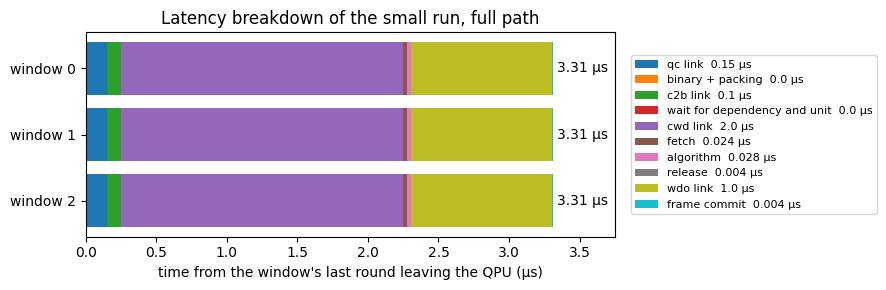

In [21]:
figure, axis = plt.subplots(figsize=(9, 3))
colors = plt.cm.tab10.colors

for row, window_id in enumerate(windows):
    start = 0.0
    for stage_index, (stage, duration) in enumerate(breakdown(window_id)):
        label = None
        if row == 0:
            label = stage + "  " + str(duration) + " µs"
        axis.barh(row, duration, left=start, color=colors[stage_index], label=label)
        start = start + duration
    axis.text(start + 0.03, row, str(round(start, 3)) + " µs", va="center")

axis.set_yticks(range(len(windows)))
axis.set_yticklabels(["window " + str(window_id) for window_id in windows])
axis.invert_yaxis()
axis.set_xlim(0, 3.75)
axis.set_xlabel("time from the window's last round leaving the QPU (µs)")
axis.set_title("Latency breakdown of the small run, full path")
axis.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
figure.tight_layout()
figure.savefig(repo_root / "guide" / "walkthrough" / "figures" / "small_run_breakdown.png", dpi=200)
plt.show()

## The whole run on one timeline

The same waterfall, but for the entire shot on an absolute time axis:
gray bars are the twelve rounds traveling QPU -> Buffer 0, colored bars are
each window's stages at their real times. The pipelining is visible:
window 1's buffer is filling while window 0 decodes. The numbers label
window 0's durations; windows 1 and 2 are identical, one and two window
periods later.

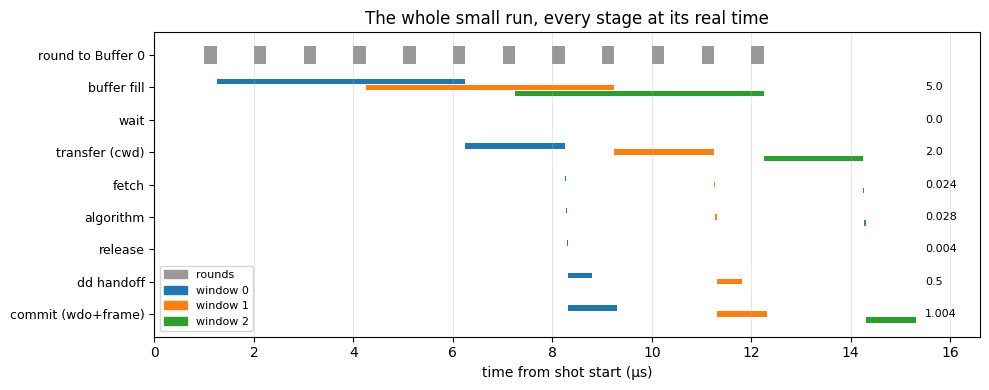

In [22]:
ROWS = ("round to Buffer 0", "buffer fill", "wait", "transfer (cwd)",
        "fetch", "algorithm", "release", "dd handoff", "commit (wdo+frame)")
WINDOW_COLORS = ("tab:blue", "tab:orange", "tab:green")

figure, axis = plt.subplots(figsize=(10, 4))


def bar(row, start, end, color):
    axis.barh(row, end - start, left=start, color=color, height=0.55)
    return end - start


for round_index in sorted(qc):
    bar(0, us(qc[round_index]["send_ticks"]), us(c2b[round_index]["delivery_ticks"]), "0.6")

for window_id, window in windows.items():
    color = WINDOW_COLORS[window_id]

    # windows can overlap in time on the same row, so each window gets its
    # own thin lane inside the row
    def bar(row, start, end, color, window_id=window_id):
        lane = row + (window_id - 1) * 0.19
        axis.barh(lane, end - start, left=start, color=color, height=0.17)
        return end - start

    stages = {record.stage: record
              for record in decoder_engine.stage_records_for(operation.id, window_id)}
    durations = {}
    durations["buffer fill"] = bar(1, us(window.t_first_round), us(window.t_data_complete), color)
    durations["wait"] = bar(2, us(window.t_data_complete), us(window.t_dispatch), color)
    durations["transfer (cwd)"] = bar(3, us(cwd[window_id]["send_ticks"]),
                                      us(cwd[window_id]["delivery_ticks"]), color)
    for row, stage in ((4, "fetch"), (5, "algorithm"), (6, "release")):
        durations[stage] = bar(row, us(stages[stage].start_ticks), us(stages[stage].end_ticks), color)
    if window_id in dd:
        durations["dd handoff"] = bar(7, us(dd[window_id]["send_ticks"]),
                                      us(dd[window_id]["delivery_ticks"]), color)
    durations["commit (wdo+frame)"] = bar(8, us(wdo[window_id]["send_ticks"]),
                                          us(frame_records[window_id].committed_ticks), color)
    if window_id == 0:
        for row, name in enumerate(ROWS[1:], start=1):
            if name in durations:
                axis.text(15.5, row, str(round(durations[name], 3)), va="center", fontsize=8)

axis.set_yticks(range(len(ROWS)))
axis.set_yticklabels(ROWS, fontsize=9)
axis.invert_yaxis()
axis.set_xlim(0, 16.6)
axis.set_xlabel("time from shot start (µs)")
axis.set_title("The whole small run, every stage at its real time")
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in ("0.6",) + WINDOW_COLORS]
axis.legend(handles, ("rounds", "window 0", "window 1", "window 2"),
            loc="lower left", fontsize=8)
axis.grid(alpha=0.3, axis="x")
figure.tight_layout()
figure.savefig(repo_root / "guide" / "walkthrough" / "figures" / "small_run_timeline.png", dpi=200)
plt.show()

## End to end, against the hand arithmetic

This run condensed to one row per window, next to README section 1's
closed-form answer key. The defect changed the data, not one timestamp.

In [23]:
from analytic_small_run import COLUMNS, analytic_timeline, print_table

run_rows = []
for window_id, window in windows.items():
    record = frame_records[window_id]
    dd_delivery = None
    if window_id in dd:
        dd_delivery = us(dd[window_id]["delivery_ticks"])
    run_rows.append({
        "window_id": window_id,
        "read_lo": window.start_round,
        "read_hi": min(window.buffer_hi, last_round),
        "commit_lo": window.commit_lo,
        "commit_hi": window.commit_hi,
        "buffer0_ready_us": us(window.t_data_complete),
        "queued_us": us(window.t_queued),
        "dispatch_us": us(window.t_dispatch),
        "decode_done_us": us(window.t_done),
        "dd_delivery_us": dd_delivery,
        "frame_commit_us": us(record.committed_ticks),
        "buffer0_ready_to_frame_us": us(record.committed_ticks - window.t_data_complete),
    })

hand_rows = analytic_timeline(config)
print("This run:")
print_table(run_rows)
print()
print("By hand:")
print_table(hand_rows)
print()

mismatches = []
for hand_row, run_row in zip(hand_rows, run_rows):
    for column in COLUMNS:
        hand_value = hand_row[column]
        run_value = run_row[column]
        if isinstance(hand_value, float):
            hand_value = round(hand_value, 6)
        if hand_value != run_value:
            mismatches.append((run_row["window_id"], column, hand_value, run_value))

if mismatches:
    print("MISMATCHES:", mismatches)
else:
    print("MATCH: every cell agrees to the tick.")

This run:
| window_id | read_lo | read_hi | commit_lo | commit_hi | buffer0_ready_us | queued_us | dispatch_us | decode_done_us | dd_delivery_us | frame_commit_us | buffer0_ready_to_frame_us |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 1 | 6 | 1 | 3 | 6.250 | 6.250 | 6.250 | 8.306 | 8.806 | 9.310 | 3.060 |
| 1 | 4 | 9 | 4 | 6 | 9.250 | 9.250 | 9.250 | 11.306 | 11.806 | 12.310 | 3.060 |
| 2 | 7 | 12 | 7 | 12 | 12.250 | 12.250 | 12.250 | 14.306 |  | 15.310 | 3.060 |

By hand:
| window_id | read_lo | read_hi | commit_lo | commit_hi | buffer0_ready_us | queued_us | dispatch_us | decode_done_us | dd_delivery_us | frame_commit_us | buffer0_ready_to_frame_us |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 1 | 6 | 1 | 3 | 6.250 | 6.250 | 6.250 | 8.306 | 8.806 | 9.310 | 3.060 |
| 1 | 4 | 9 | 4 | 6 | 9.250 | 9.250 | 9.250 | 11.306 | 11.806 | 12.310 | 3.060 |
| 2 | 7 | 12 | 7 | 12 | 12.250 | 12.250 | 12.250 | 14.306 |  | 15.310 | 3.060 |

MATCH: every cell agrees to the tic